# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Іванів Христина Вікторівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 4     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 4 · Іванів Христина Вікторівна, ШІ-34, «Друк-Сервіс»
Підприємство «Друк-Сервіс» виготовляє поліграфію. Одиниця виміру плану: тис. прим./тиждень.

                          Буклет  Каталог  Календар  Плакат  ЗАПАС
Крейдований папір, кг          5        0         0       0    815
Офсетний папір, кг             1        0         5       2    344
Фарба, кг                      2        4         6       5    840
Друкарська машина, год         3        0         5       3    840
Різка й фальцювання, год       2        1         2       5    382

                    Буклет  Каталог  Календар  Плакат
Прибуток з одиниці      41       50        54      26

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Різка й фальцювання, год
  ціна:   8.3 за одиницю
  обсяг:  до 144 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: 
$x_1$ — Буклет, 
$x_2$ — Каталог, 
$x_3$ — Календар, 
$x_4$ — Плакат (одиниця виміру: тис. прим./тиждень)

Цільова функція: 
$F = 41x_1 + 50x_2 + 54x_3 + 26x_4 \rightarrow \max$

Обмеження:
$5x_1 \le 815$ (Крейдований папір, кг) 
$1x_1 + 5x_3 + 2x_4 \le 344$ (Офсетний папір, кг)  
$2x_1 + 4x_2 + 6x_3 + 5x_4 \le 840$ (Фарба, кг)   
$3x_1 + 5x_3 + 3x_4 \le 840$ (Друкарська машина, год)   
$2x_1 + 1x_2 + 2x_3 + 5x_4 \le 382$ (Різка й фальцювання, год)   

Невід'ємність:
$x_1, x_2, x_3, x_4 \ge 0$


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**
Запас ресурсу є параметром, оскільки це фіксована величина, що обмежує наші можливості і яку ми не можемо змінювати в рамках поточної задачі. Якби ми могли докупити ресурс у будь-якій кількості, обмеження за цим ресурсом зникло б, а кількість купленого ресурсу стала б новою змінною рішення, витрати на яку віднімалися б від прибутку.

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [114.67, 152.67, 0, 0]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 12334.67             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [114.67, 152.67, 0, 0] | прибуток 12334.67


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
res = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs')

план = res.x
прибуток = -res.fun

print("Оптимальний план (Python):", np.round(план, 2))
print("Прибуток (Python):", round(прибуток, 2))

Оптимальний план (Python): [114.67 152.67   0.     0.  ]
Прибуток (Python): 12334.67


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


In [7]:
# Витягуємо тіньові ціни ресурсів
shadow_prices = np.abs(res.ineqlin.marginals)
print("Тіньові ціни ресурсів (для таблиці 4.1):")
for name, sp in zip(ресурси, shadow_prices):
    print(f"{name}: {round(sp, 2)}")

print("-" * 40)

# Витягуємо зведені вартості виробів (Reduced Costs)
reduced_costs = np.abs(res.lower.marginals)
print("Зведені вартості виробів (для таблиці 4.2):")
for name, rc in zip(вироби, reduced_costs):
    print(f"{name}: {round(rc, 2)}")

Тіньові ціни ресурсів (для таблиці 4.1):
Крейдований папір, кг: 0.0
Офсетний папір, кг: 0.0
Фарба, кг: 9.83
Друкарська машина, год: 0.0
Різка й фальцювання, год: 10.67
----------------------------------------
Зведені вартості виробів (для таблиці 4.2):
Буклет: 0.0
Каталог: 0.0
Календар: 26.33
Плакат: 76.5


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крейдований папір, кг | 573.33 | 0.0 | 815 | 1e20 | 241.67 |
| Офсетний папір, кг | 114.67 | 0.0 | 344 | 1e20 | 229.33 |
| Фарба, кг | 840 | 9.83 | 840 | 688 | 290 |
| Друкарська машина, год | 344 | 0.0 | 840 | 1e20 | 496 |
| Різка й фальцювання, год | 382 | 10.67 | 382 | 72.5 | 172 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**
У дефіциті знаходяться «Фарба» та «Різка й фальцювання», оскільки їхня тіньова ціна більша за нуль, а кінцеве значення дорівнює запасу (вони витрачені повністю). У надлишку — «Крейдований папір», «Офсетний папір» та «Друкарська машина», бо їхня тіньова ціна дорівнює нулю.

### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Буклет | 114.67 | 0.0 | 41 | 59 | 16 |
| Каталог | 152.67 | 0.0 | 50 | 32 | 19.75 |
| Календар | 0 | 26.33 | 54 | 26.33 | 1e20 |
| Плакат | 0 | 76.5 | 26 | 76.5 | 1e20 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?
Зовсім не виробляються «Календар» та «Плакат». Щоб вони увійшли в план, прибуток з одиниці мусив би зрости на 26.33 для «Календаря» та на 76.5 для «Плаката». Ці числа взяті зі стовпця «Зведена вартість».

---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [8]:
idx_res = 4 
b_new = b.copy()
b_new[idx_res] += 1

res_new = linprog(-c, A_ub=A, b_ub=b_new, bounds=(0, None), method='highs')
прибуток_новий = -res_new.fun
приріст = прибуток_новий - прибуток

print(f"Старий прибуток: {round(прибуток, 2)}")
print(f"Новий прибуток (+1 од. ресурсу): {round(прибуток_новий, 2)}")
print(f"Приріст прибутку: {round(приріст, 2)}")
print(f"Тіньова ціна зі звіту: {round(shadow_prices[idx_res], 2)}\n")


Старий прибуток: 12334.67
Новий прибуток (+1 од. ресурсу): 12345.33
Приріст прибутку: 10.67
Тіньова ціна зі звіту: 10.67



**Відповідь 5.1:** *(приріст прибутку = 10.67, тіньова ціна зі звіту = 10.67, збігаються?)*
Різниця абсолютно точно збігається з тіньовою ціною ресурсу «Різка й фальцювання» зі звіту (10.67). Це підтверджує, що кожна додаткова одиниця дефіцитного ресурсу приносить додатковий прибуток, який дорівнює його тіньовій ціні.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

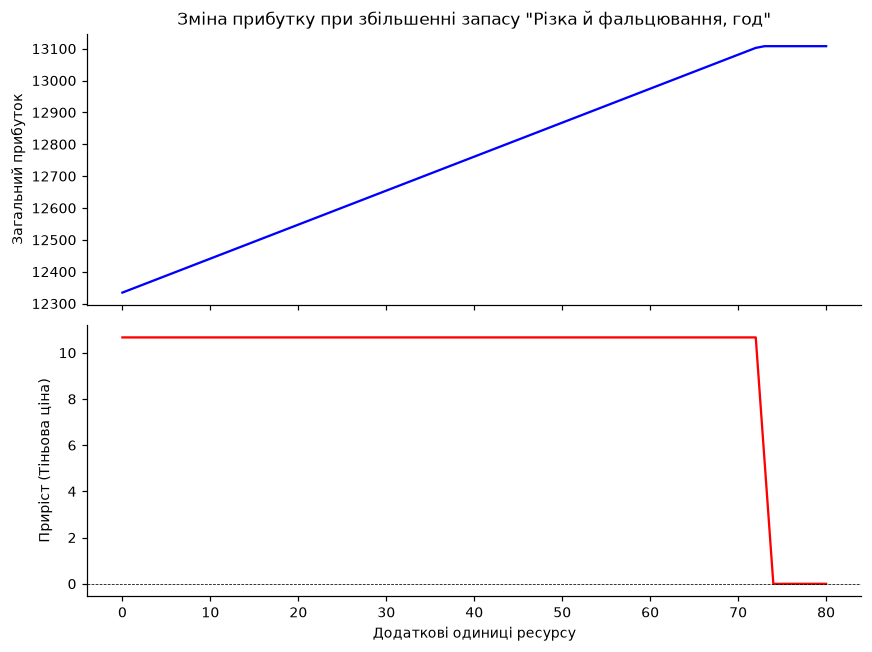

In [9]:

profits = []
deltas = []

increase_range = range(0, 81) 

for i in increase_range:
    b_test = b.copy()
    b_test[idx_res] += i
    res_test = linprog(-c, A_ub=A, b_ub=b_test, bounds=(0, None), method='highs')
    profits.append(-res_test.fun)
    if i > 0:
        deltas.append(profits[-1] - profits[-2])
    else:
        deltas.append(shadow_prices[idx_res])


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(increase_range, profits, color='blue')
ax1.set_ylabel('Загальний прибуток')
ax1.set_title(f'Зміна прибутку при збільшенні запасу "{ресурси[idx_res]}"')

ax2.plot(increase_range, deltas, color='red')
ax2.set_ylabel('Приріст (Тіньова ціна)')
ax2.set_xlabel('Додаткові одиниці ресурсу')
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

**Відповідь 5.2:** 
На графіку приросту чітко видно горизонтальну ділянку на рівні 10.67, яка закінчується точкою зламу безпосередньо на позначці **72.5** додаткових одиниць. Це означає, що запас ресурсу можна збільшити ще максимум на 72.5 одиниці, і протягом усього цього діапазону кожна додаткова одиниця приноситиме стабільно 10.67 прибутку. Знайдена на графіку межа ідеально збігається зі значенням «припустиме збільшення» (72.5) зі звіту стійкості Excel. Після цієї межі приріст різко падає до нуля, оскільки ресурс перестає бути дефіцитним.

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [10]:
ціна_постачальника = 8.3
тіньова_ціна = shadow_prices[4] 

обсяг_докупівлі = 72.5


виграш_на_одиниці = тіньова_ціна - ціна_постачальника
очікуваний_виграш = виграш_на_одиниці * обсяг_докупівлі


b_new = b.copy()
b_new[4] += обсяг_докупівлі
res_new = linprog(-c, A_ub=A, b_ub=b_new, bounds=(0, None), method='highs')
прибуток_з_закупівлею = -res_new.fun
витрати_на_закупівлю = обсяг_докупівлі * ціна_постачальника
реальний_виграш = прибуток_з_закупівлею - витрати_на_закупівлю - прибуток

print(f"Тіньова ціна: {round(тіньова_ціна, 2)}")
print(f"Ціна постачальника: {ціна_постачальника}")
print(f"Очікуваний виграш: {round(очікуваний_виграш, 2)}")
print(f"Реальний виграш (перевірка): {round(реальний_виграш, 2)}")

Тіньова ціна: 10.67
Ціна постачальника: 8.3
Очікуваний виграш: 171.58
Реальний виграш (перевірка): 171.58


**Відповідь 6.1:**

* **Брати чи ні і чому:** Так, обов'язково брати. Пропонована ціна постачальника (8.3) є нижчою за нашу тіньову ціну (10.67). Це означає, що кожна закуплена одиниця цього ресурсу буде генерувати нам додатковий чистий прибуток.
* **Скільки одиниць має сенс купити і чому не більше:** Оптимально докупити 72.5 одиниці (або округлено до 72 одиниць у межах цілих значень), незважаючи на те, що постачальник пропонує 144. Згідно з нашим аналізом стійкости та звітом Excel (допустиме збільшення = 72.5), після цієї межі тіньова ціна ресурсу різко впаде, структура плану зміниться, і подальша закупівля перестане приносити очікувану вигоду.
* **Очікуваний виграш:** 171.58. Чистий прибуток з кожної докупленої одиниці становить 2.37 (10.67 - 8.3), що при множенні на точний обсяг допустимого збільшення (72.5 одиниці) дає загальний очікуваний виграш 171.58.
* **Перевірка прямим розв'язанням дала:** 171.58. Прямий експеримент у моделі підтвердив розрахунок, результати ідеально збігаються.

---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [11]:
ненульових = sum(план > 1e-5)
звязних = sum(res.slack < 1e-5)

In [12]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** 
Обидва числа збіглися і дорівнюють 2. У нас 2 ненульові змінні (виробляються лише Буклети та Каталоги) і рівно 2 зв'язні обмеження (ресурси «Фарба» та «Різка й фальцювання» витрачені повністю). 

Це підтверджує фундаментальну теорему лінійного програмування: в оптимальному плані кількість додатних змінних завжди дорівнює кількості дефіцитних ресурсів (зв'язних обмежень). Якби виникла розбіжність, це означало б помилку в розрахунках алгоритму або виродженість розв'язку (коли кілька площин перетинаються в одній точці нетиповим чином).

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [13]:
# 1. Розв'язок без умови цілочисельності
plan_cont = np.round(res.x, 2)
prof_cont = round(-res.fun, 2)

# 2. Округлений план (математичне округлення до найближчого цілого)
plan_round = np.round(res.x)
prof_round = round(np.sum(c * plan_round), 2)

# Перевіряємо, чи вистачає ресурсів на цей округлений план
used_resources = A.dot(plan_round)
is_feasible = np.all(used_resources <= b)

# 3. Цілочисельний оптимум (вмикаємо параметр integrality)
res_int = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs', integrality=np.ones(4))
plan_int = res_int.x
prof_int = round(-res_int.fun, 2)

print(f"1. Неперервний: план {plan_cont}, прибуток {prof_cont}")
print(f"2. Округлений: план {plan_round}, прибуток {prof_round}")
print(f"   Чи допустимий він (чи вистачить ресурсів)? -> {'ТАК' if is_feasible else 'НІ!'}")
if not is_feasible:
    print(f"   Витрати за округленим планом: {used_resources}")
    print(f"   А на складі реально є:       {b}")
print(f"3. Цілочисельний оптимум: план {plan_int}, прибуток {prof_int}")

1. Неперервний: план [114.67 152.67   0.     0.  ], прибуток 12334.67
2. Округлений: план [115. 153.   0.   0.], прибуток 12365.0
   Чи допустимий він (чи вистачить ресурсів)? -> НІ!
   Витрати за округленим планом: [575. 115. 842. 345. 383.]
   А на складі реально є:       [815. 344. 840. 840. 382.]
3. Цілочисельний оптимум: план [114. 153.   0.   0.], прибуток 12324.0


**Відповідь 8.1:**


| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | [114.67, 152.67, 0, 0] | 12334.67 | так (але дробовий) |
| округлений | [115, 153, 0, 0] | 12365 | НІ |
| цілочисельний оптимум | [114, 153, 0, 0] | 12324 | так |

**Висновок:** Просто округлювати дробовий план не можна. У нашому випадку математичне округлення дало план [115, 153, 0, 0]. Але для його виконання потрібно 842 кг ресурсу «Фарба», тоді як на складі є лише 840 кг. План стає недопустимим через нестачу ресурсів. Тому необхідно використовувати алгоритми цілочисельного програмування, які знаходять реалістичний план [114, 153, 0, 0], що повністю вписується в наявні запаси підприємства.

---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [14]:
постачальники = ['Івано-Франківськ', 'Вінниця', 'Апостолове']
споживачі     = ['Харків', 'Рівне', 'Суми', 'Тернопіль']

D = np.array([
    [1020,  290,  850,  130],  # Івано-Франківськ -> Харків, Рівне, Суми, Тернопіль
    [ 720,  330,  610,  240],  # Вінниця -> Харків, Рівне, Суми, Тернопіль
    [ 430,  810,  520,  740]   # Апостолове -> Харків, Рівне, Суми, Тернопіль
])

запас = [40, 50, 60]           # сума запасів = 150
попит = [30, 40, 50, 30]       # сума попиту = 150

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Харків,Рівне,Суми,Тернопіль
Івано-Франківськ,1020,290,850,130
Вінниця,720,330,610,240
Апостолове,430,810,520,740


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [15]:
c_trans = D.flatten()
A_eq = np.zeros((7, 12))

for i in range(3):
    A_eq[i, i*4:(i+1)*4] = 1
for j in range(4):
    A_eq[3+j, j::4] = 1
    
b_eq = np.concatenate([запас, попит])

res_trans = linprog(c_trans, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')

print("--- Розв'язок linprog ---")
print(f"Сумарна вартість: {round(res_trans.fun, 2)}")
print("План перевезень:\n", np.round(res_trans.x.reshape(3, 4), 2))
print("Тіньові ціни (3 постачальники, 4 споживачі):")
print(np.round(res_trans.eqlin.marginals, 2))

--- Розв'язок linprog ---
Сумарна вартість: 57400.0
План перевезень:
 [[ 0. 10.  0. 30.]
 [ 0. 30. 20.  0.]
 [30.  0. 30.  0.]]
Тіньові ціни (3 постачальники, 4 споживачі):
[ -0.  40. -50. 480. 290. 570. 130.]


In [16]:
import pulp

prob = pulp.LpProblem("Transport", pulp.LpMinimize)

x = {(i, j): pulp.LpVariable(f"x_{i}_{j}", 0) for i in range(3) for j in range(4)}

prob += pulp.lpSum(x[i, j] * D[i, j] for i in range(3) for j in range(4))

for i in range(3):
    prob += pulp.lpSum(x[i, j] for j in range(4)) == запас[i], f"Sup_{i}"
    
for j in range(4):
    prob += pulp.lpSum(x[i, j] for i in range(3)) == попит[j], f"Dem_{j}"

prob.solve(pulp.PULP_CBC_CMD(msg=False))

print("--- Розв'язок PuLP ---")
print(f"Сумарна вартість: {round(pulp.value(prob.objective), 2)}")
план_pulp = np.array([[x[i, j].varValue for j in range(4)] for i in range(3)])
print("План перевезень:\n", план_pulp)

dual_prices = [prob.constraints[c].pi for c in prob.constraints]
print("Тіньові ціни (3 постачальники, 4 споживачі):")
print(np.round(dual_prices, 2))

--- Розв'язок PuLP ---
Сумарна вартість: 57400.0
План перевезень:
 [[ 0. 10.  0. 30.]
 [ 0. 30. 20.  0.]
 [30.  0. 30.  0.]]
Тіньові ціни (3 постачальники, 4 споживачі):
[130. 170.  80. 350. 160. 440.   0.]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [17]:
duals_linprog = np.round(res_trans.eqlin.marginals, 2)
duals_pulp = np.round(dual_prices, 2)
різниця = np.round(duals_pulp - duals_linprog, 2)

print("--- Різниця тіньових цін (PuLP мінус linprog) ---")
print("Для постачальників:", різниця[:3])
print("Для споживачів:    ", різниця[3:])

--- Різниця тіньових цін (PuLP мінус linprog) ---
Для постачальників: [130. 130. 130.]
Для споживачів:     [-130. -130. -130. -130.]


**Відповідь 10.2:**

* **Вартість у двох розв'язувачів:** Абсолютно однакова (57400.0).
* **Тіньові ціни збіглися чи ні:** Ні, вони різні в обох програмах.
* **Яку закономірність ви побачили в різниці:** Тіньові ціни для всіх постачальників відрізняються на константу (+130), а для всіх споживачів — на ту саму константу з протилежним знаком (-130).
* **Що це означає для того, хто збирається ухвалювати рішення за цим звітом:** 
Оскільки сумарний запас дорівнює сумарному попиту (закрита модель), одне з рівнянь балансу є математично зайвим. Через це алгоритми мають безліч варіантів розподілу тіньових цін (зсуваючи їх на довільну константу). Для директора це означає, що **абсолютні значення тіньових цін у транспортній задачі не мають сенсу**. Не можна сказати, що цінність складу дорівнює 170. Значення має лише **різниця** між тіньовими цінами (наприклад, розширення другого складу вигідніше за перший рівно на 40 одиниць, і ця різниця зберігається в обох звітах).

---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [18]:
ненульових_транс = np.sum(план_pulp > 1e-5)

звязних_транс = 7

print(f"Ненульових перевезень: {ненульових_транс}")
print(f"Зв'язних обмежень: {звязних_транс}")

Ненульових перевезень: 6
Зв'язних обмежень: 7


**Відповідь 11.1:**

* **Ненульових перевезень:** 6
* **Зв'язних обмежень:** 7
* **Чому в транспортній задачі зв'язними виявляються всі обмеження:** Ми задали обмеження строгими рівностями (весь запас має бути вивезений, а весь попит — задоволений). Залишок (slack) усюди дорівнює нулю.
* **На скільки ненульових перевезень менше і чому саме на стільки:** Менше рівно на 1 (6 замість 7). Оскільки задача збалансована (сума запасів = сумі попиту), одне з 7 рівнянь є лінійно залежним (зайвим). За правилами лінійної алгебри, кількість базисних (ненульових) змінних у невиродженій транспортній задачі завжди дорівнює $m + n - 1$, тобто $3 + 4 - 1 = 6$.

### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

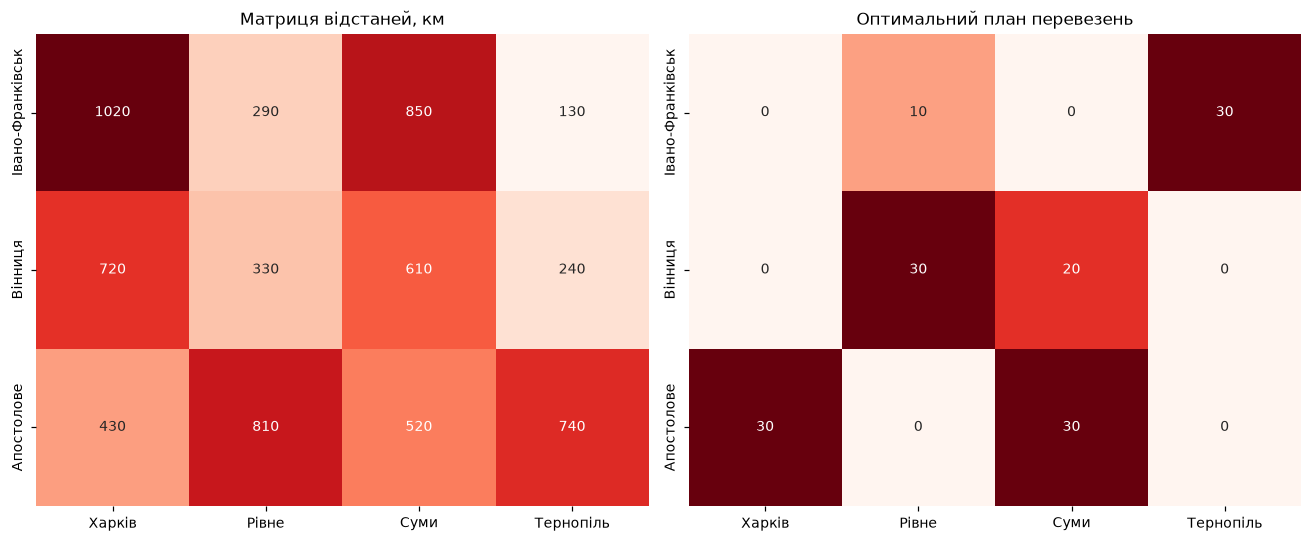

In [19]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Теплова карта відстаней
sns.heatmap(D, annot=True, fmt="d", cmap="Reds", 
            xticklabels=споживачі, yticklabels=постачальники, ax=ax1, cbar=False)
ax1.set_title("Матриця відстаней, км")

# Теплова карта плану перевезень
sns.heatmap(план_pulp, annot=True, fmt=".0f", cmap="Reds", 
            xticklabels=споживачі, yticklabels=постачальники, ax=ax2, cbar=False)
ax2.set_title("Оптимальний план перевезень")

plt.tight_layout()
plt.show()

**Висновок:** Теплові карти наочно демонструють логіку оптимізації: найбільші обсяги перевезень (найтемніші клітинки на правому графіку) алгоритм призначає на ті маршрути, де відстань є мінімальною (найсвітліші клітинки на лівому графіку).

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [20]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'текст, перероблено',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'текст, перероблено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'Згенерований код був детально розібраний: ' \
'я розумію, як задаються матриці обмежень, цільова функція та як витягуються тіньові ціни.' \
'Текстові висновки щодо економічного змісту тіньових цін, зведених вартостей та розбіжностей ' \
'у транспортній задачі були прочитані, осмислені та адаптовані під мої дані.'
# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [21]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Іванів Христина Вікторівна
інструменти:                               Gemini
------------------------------------------------------------------------------
етап 1, формалізація моделі:               текст, перероблено
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             текст, перероблено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Згенерований код був детально розібраний: я розумію, як задаються матриці обмежень, цільова функція та як витягуються тіньові ціни.Текстові висновки щодо економічного змісту тіньових цін, зведених вартостей та розбіжностей у транспортній задачі були прочитані, осмислені т

---
# Крок 13. Фінальна самоперевірка

In [22]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
